# Simple Logistic Regression

## Nạp thư viện

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## 2.Nạp dữ liệu

In [2]:
dataset = pd.read_csv('/content/Admittance.csv')
dataset.head()

,SAT,Admitted
0,1363,No
1,1792,Yes
2,1954,Yes
3,1653,No
4,1593,No


In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   SAT       168 non-null    int64 
 1   Admitted  168 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.8+ KB


In [4]:
#Tiền xử lý mã hóa categorical của biến phụ thuộc Admitted thành dạng số
dataset['Admitted'] = dataset['Admitted'].map({'Yes':1,'No':0})
dataset.head(5)

,SAT,Admitted
0,1363,0
1,1792,1
2,1954,1
3,1653,0
4,1593,0


## 3. Tách tập huấn luyện và tập kiểm thử

In [5]:
#Tách biến
X = dataset.iloc[:,:-1].values
y = dataset.iloc[:,-1].values

In [9]:
X[:5] #Hiển thị 5 dòng đầu tiên của X

array([[1363],
       [1792],
       [1954],
       [1653],
       [1593]])

In [10]:
y[:5] #Hiển thị 5 dòng đầu của y

array([0, 1, 1, 0, 0])

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2,random_state=0)


In [7]:
print(X_train.shape)

(134, 1)


In [11]:
print(X_test.shape)

(34, 1)


## 5. Chuẩn hóa dữ liệu (Feature Scaling)
-Vì tập dữ liệu chỉ có 1 đặc trưng nên không cần chuẩn hóa

## 6. Huấn luyện mô hình Linear Regression và Logistic Regression

In [12]:
#Linear Regression
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train,y_train)


LinearRegression()

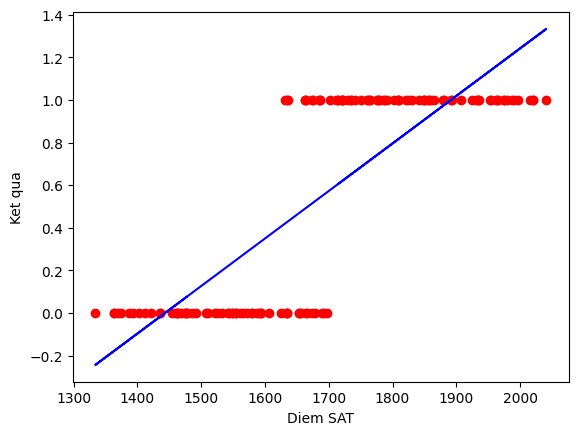

In [15]:
#Trực quan hóa kết quả của mô hình Linear Regression
plt.scatter(X_train,y_train,color='red')
plt.plot(X_train,regressor.predict(X_train),color='blue') #Vẽ đường hồi quy
plt.xlabel('Diem SAT')
plt.ylabel('Ket qua')
plt.show()

Dựa vào hình trực quan trên có thể thấy mô hình linear regression không phù hợp với dữ liệu phân lớp nhị phân

In [16]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state=0)
classifier.fit(X_train,y_train)


LogisticRegression(random_state=0)

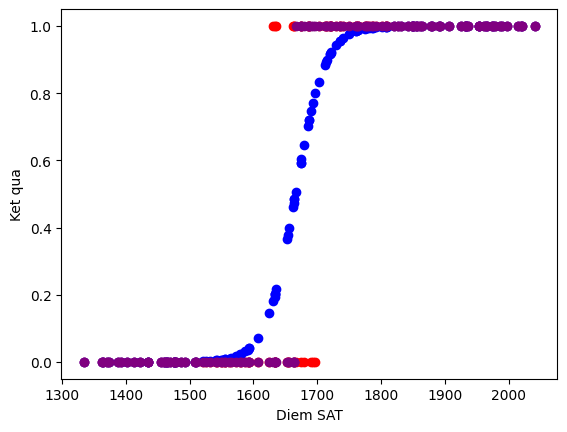

In [21]:
#Trwucj quan hóa Linear Regression
plt.scatter(X_train,y_train,color='red')
#Dự đoán trên phân phối xác suất
plt.scatter(X_train,classifier.predict_proba(X_train)[:,1],color='blue')
plt.scatter(X_train,classifier.predict(X_train),color='purple')
plt.xlabel('Diem SAT')
plt.ylabel('Ket qua')
plt.show()

In [20]:
classifier.predict_proba(X_train)

array([[1.02313529e-01, 8.97686471e-01],
       [1.76994604e-03, 9.98230054e-01],
       [8.38694330e-02, 9.16130567e-01],
       [4.36016422e-04, 9.99563984e-01],
       [2.79949101e-01, 7.20050899e-01],
       [2.46696938e-04, 9.99753303e-01],
       [4.07332093e-01, 5.92667907e-01],
       [1.67692465e-01, 8.32307535e-01],
       [9.99984991e-01, 1.50094474e-05],
       [8.05615453e-01, 1.94384547e-01],
       [9.99994982e-01, 5.01832493e-06],
       [1.34095275e-06, 9.99998659e-01],
       [9.68861008e-01, 3.11389915e-02],
       [1.78617125e-07, 9.99999821e-01],
       [9.99976736e-01, 2.32640446e-05],
       [7.98660655e-01, 2.01339345e-01],
       [2.07843889e-06, 9.99997922e-01],
       [9.83617390e-01, 1.63826105e-02],
       [9.97786377e-01, 2.21362266e-03],
       [9.99853448e-01, 1.46552394e-04],
       [2.51128879e-03, 9.97488711e-01],
       [4.07332093e-01, 5.92667907e-01],
       [5.57699246e-02, 9.44230075e-01],
       [8.38694330e-02, 9.16130567e-01],
       [9.999012

In [23]:
#Tính W0(B0) và W1(b1)
b0 = classifier.intercept_
b1 = classifier.coef_
print(b0)
print(b1)

[-72.98594337]
[[0.04382374]]


In [26]:
import math
#Thử dự đoán 1 điểm  SAT = 1300 ?
math.exp(b0+b1*1300)/(1+math.exp(b0+b1*1300)) #Bé hơn 0.5 nên mô hình sẽ dự đoán là thuộc phân lớp 0

/tmp/ipykernel_604/1225881329.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  math.exp(b0+b1*1300)/(1+math.exp(b0+b1*1300)) #Bé hơn 0.5 nên mô hình sẽ dự đoán là thuộc phân lớp 0


1.1085140247474002e-07

In [27]:
math.exp(b0+b1*1900)/(1+math.exp(b0+b1*1900)) #Lớn hơn 0.5 nên thuộc phân lớp 1

/tmp/ipykernel_604/2337126189.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  math.exp(b0+b1*1900)/(1+math.exp(b0+b1*1900))


0.9999656602188853

In [29]:
#Sử dụng thư viện để dự đoán điểm SAT = 1900
y_hat = classifier.predict([[1900]])
print(y_hat)

[1]


## 7. Dự đoán trên tập kiểm thử

In [32]:
y_pred = classifier.predict(X_test)
print(X_test[:5])
print(y_pred[:5])


[[1933]
 [1670]
 [1430]
 [1550]
 [1775]]
[1 1 0 0 1]


In [33]:
print(X_test[:5])
print(y_test[:5])

[[1933]
 [1670]
 [1430]
 [1550]
 [1775]]
[1 0 0 0 1]


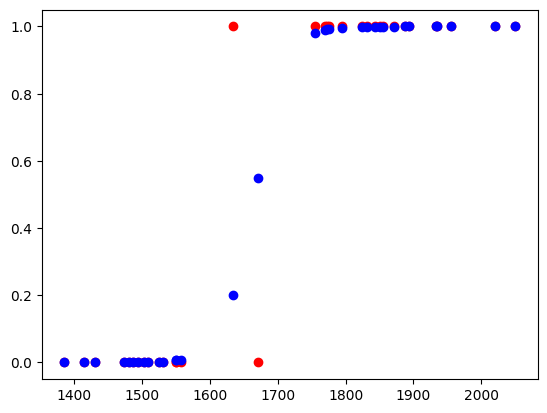

In [36]:
#Trực quan hóa tập kiểm thử
plt.scatter(X_test,y_test,color='red')
plt.scatter(X_test,classifier.predict_proba(X_test)[:,1],color='blue')

## 8. Đánh giá mô hình

In [37]:
from sklearn.metrics import confusion_matrix,precision_score,recall_score,accuracy_score,f1_score

In [38]:
cm = confusion_matrix(y_test,y_pred)
print(confusion_matrix(y_test,y_pred))
print(precision_score(y_test,y_pred))
print(recall_score(y_test,y_pred))
print(accuracy_score(y_test,y_pred))
print(f1_score(y_test,y_pred))

[[14  1]
 [ 1 18]]
0.9473684210526315
0.9473684210526315
0.9411764705882353
0.9473684210526315


In [39]:
cm = confusion_matrix(y_test,y_pred)
df_cm = pd.DataFrame(cm, index=['Actual: No','Actual: Yes'],columns=['Predicted: No','Predicted: Yes'])
df_cm

,Predicted: No,Predicted: Yes
Actual: No,14,1
Actual: Yes,1,18


In [40]:
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
accuracy = accuracy_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
print('Precision: ',precision)
print('Recall: ',recall)
print('Accuracy: ',accuracy)
print('F1: ',f1)

Precision:  0.9473684210526315
Recall:  0.9473684210526315
Accuracy:  0.9411764705882353
F1:  0.9473684210526315


<Axes: >

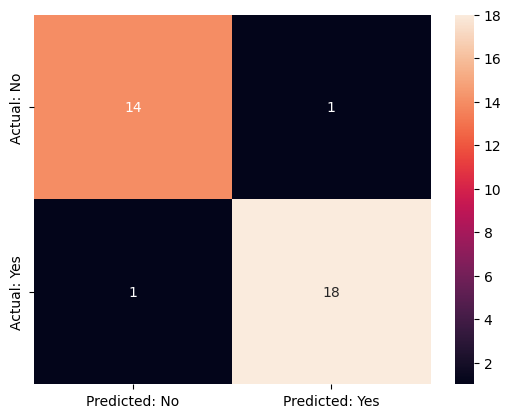

In [41]:
#Vẽ trực quan hóa biểu đồ ma trận nhầm lẫn sử dụng thư viện searborn
import seaborn as sns
sns.heatmap(df_cm,annot=True)


## Sử dụng độ đo là đường công ROC/AUC

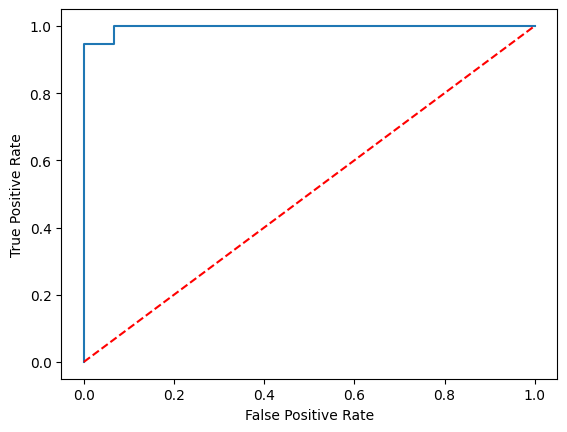

In [44]:
from sklearn.metrics import roc_curve,roc_auc_score
#fpr gọi là false positive rate
#tpr gọi là true positive rate
#thresholds là các ngưỡng từ [0,1]
fpr,tpr,thresholds = roc_curve(y_test,classifier.predict_proba(X_test)[:,1])
#auc là diện tích bên dưới đường con Roc
auc = roc_auc_score(y_test,classifier.predict_proba(X_test)[:,1])


plt.plot(fpr,tpr,label='ROC curve (area = %0.2f)'%auc)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.plot([0,1],[0,1], color='red',linestyle='--') #Random classifier

plt.show()

Bây giờ muốn mô hình giảm FP thì ta tăng ngưỡng Threshold lên

In [45]:
y_pred_prob = classifier.predict_proba(X_test)[:,1]
new_thresholds = 0.7 #mặc định 0.5

y_pred_new = (y_pred_prob >= new_thresholds).astype(int)

cm_new = confusion_matrix(y_test,y_pred_new)
print(cm_new)


[[15  0]
 [ 1 18]]


In [46]:
#đánh giá lại mô hình với ngưỡng mới
precision_new = precision_score(y_test,y_pred_new)
recall_new = recall_score(y_test,y_pred_new)
f1_new = f1_score(y_test,y_pred_new)
print('Precision: ',precision_new)
print('Recall: ',recall_new)
print('F1: ',f1_new)

Precision:  1.0
Recall:  0.9473684210526315
F1:  0.972972972972973
